### Localized wind bursts
The general picture for these is that they are going to be localized in space and time. We will parameterize a zonal wind burst as:
$$
\tau_x = \tau_0 \prod_{q\in\{x,y,t\}} \sin(\pi(q - q_0)/(q_1-q_0)) 1_{[q_0,q_1]}
$$
where $1_{[q_0,q_1]}$ is the boxcar function for the interval $[q_0,q_1]$.

This translates to the Ekman-transport forcing:
$$
(T_N, M_{Ek, x}, M_{Ek, y}) = (0, 0, -\tau_x / f).
$$
This first set of cells just sets up what is needed to construct these.

In [21]:
from pathlib import Path
from moc_adjustment_theory import EARTH_ROTATION_S, EARTH_RADIUS_M, GlobalRossbyModel, rossby_speed

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import xarray as xr

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "data").is_dir() and (path / "notebooks").is_dir()
)
TEMPLATE_FORCING_PATH = (
    PROJECT_ROOT / "data/untracked/forcing/global_ERA5_SCOTIA_forcing.nc"
)

In [2]:
def zonal_wind_burst(
    tau_0: float,
    t_0: np.datetime64,
    t_1: np.datetime64,
    lat_0: float,
    lat_1: float,
    lon_0: float,
    lon_1: float,
    template_forcing_ds: xr.Dataset | None = None,
) -> xr.Dataset:
    """
    Create a zonal wind burst forcing dataset.

    Parameters
    ----------
    tau_0 : float
        Peak eastward kinematic wind-stress anomaly in m2 s-2. Negative
        values produce an easterly burst.
    t_0 : numpy.datetime64
        The start time of the wind burst.
    t_1 : numpy.datetime64
        The end time of the wind burst.
    lat_0 : float
        The southern latitude of the wind burst region.
    lat_1 : float
        The northern latitude of the wind burst region.
    lon_0 : float
        The western longitude of the wind burst region.
    lon_1 : float
        The eastern longitude of the wind burst region.
    template_forcing_ds : xr.Dataset, optional
        Dataset supplying the time, latitude, and longitude coordinates and
        forcing-variable metadata.
        If omitted, ``TEMPLATE_FORCING_PATH`` is opened long enough to load
        its one-dimensional coordinates.

    Returns
    -------
    xr.Dataset
        A lazily evaluated dataset containing ``M_Ek_x``, ``M_Ek_y``, and
        ``T_N`` on the template grid.

    Notes
    -----
    A single signed burst generally has a non-zero time mean. Pair it with
    a compensating forcing or explicitly relax the model's zero-mean check
    when that is the intended experiment.
    """
    if not np.isscalar(tau_0) or not np.isfinite(tau_0):
        raise ValueError("tau_0 must be a finite scalar")

    t_0 = np.datetime64(t_0, "ns")
    t_1 = np.datetime64(t_1, "ns")
    spatial_bounds = np.asarray([lat_0, lat_1, lon_0, lon_1], dtype=float)
    if np.isnat(t_0) or np.isnat(t_1):
        raise ValueError("t_0 and t_1 must be valid datetimes")
    if not np.all(np.isfinite(spatial_bounds)):
        raise ValueError("latitude and longitude bounds must be finite")
    if not (t_0 < t_1 and lat_0 < lat_1 and lon_0 < lon_1):
        raise ValueError("each lower burst bound must be less than its upper bound")
    if lon_1 - lon_0 > 360.0:
        raise ValueError("longitude interval must not exceed 360 degrees")

    if template_forcing_ds is None:
        with xr.open_dataset(TEMPLATE_FORCING_PATH) as source:
            template_forcing_ds = xr.Dataset(
                coords={
                    name: source.coords[name].load().copy(deep=True)
                    for name in ("time", "latitude", "longitude")
                },
                attrs=source.attrs.copy(),
            )
            template_variable_attrs = {
                name: source[name].attrs.copy()
                for name in ("M_Ek_x", "M_Ek_y", "T_N")
                if name in source
            }
    else:
        template_variable_attrs = {
            name: template_forcing_ds[name].attrs.copy()
            for name in ("M_Ek_x", "M_Ek_y", "T_N")
            if name in template_forcing_ds
        }

    missing = {"time", "latitude", "longitude"}.difference(
        template_forcing_ds.coords
    )
    if missing:
        raise ValueError(f"template dataset is missing coordinates: {sorted(missing)}")

    bounds = {
        "time": (t_0, t_1),
        "latitude": (float(lat_0), float(lat_1)),
        "longitude": (float(lon_0), float(lon_1)),
    }
    for name, (lower, upper) in bounds.items():
        coordinate = template_forcing_ds.coords[name]
        if coordinate.dims != (name,) or coordinate.size < 2:
            raise ValueError(f"{name} must be a one-dimensional coordinate")
        values = coordinate.values
        if np.any(np.diff(values) <= 0):
            raise ValueError(f"{name} coordinate must be strictly increasing")
        if name != "longitude" and (lower < values[0] or upper > values[-1]):
            raise ValueError(
                f"{name} bounds [{lower}, {upper}] lie outside the template range "
                f"[{values[0]}, {values[-1]}]"
            )

    def sine_bump(coordinate, lower, upper, chunk_size):
        phase = (coordinate - lower) / (upper - lower)
        envelope = xr.where(
            (coordinate > lower) & (coordinate < upper),
            np.sin(np.pi * phase)**2,
            0.0,
        )
        return envelope.astype(np.float32).chunk(
            {coordinate.dims[0]: min(chunk_size, coordinate.size)}
        )

    time_profile = sine_bump(template_forcing_ds.time, t_0, t_1, 12)
    latitude_profile = sine_bump(
        template_forcing_ds.latitude, lat_0, lat_1, 64
    )
    unwrapped_longitude = (
        (template_forcing_ds.longitude - lon_0) % 360.0 + lon_0
    )
    longitude_profile = sine_bump(unwrapped_longitude, lon_0, lon_1, 128)
    time_envelope, latitude_envelope, longitude_envelope = xr.broadcast(
        time_profile, latitude_profile, longitude_profile
    )
    burst_chunks = {"time": 12, "latitude": 64, "longitude": 128}
    tau_x = np.float32(tau_0)
    for envelope in (time_envelope, latitude_envelope, longitude_envelope):
        tau_x = tau_x * envelope.chunk(burst_chunks)

    coriolis = 2.0 * EARTH_ROTATION_S * np.sin(
        np.deg2rad(template_forcing_ds.latitude)
    )
    if lat_0 < 0.0 < lat_1:
        raise ValueError("a 1/f wind burst cannot cross the equator")
    active_latitude = (
        (template_forcing_ds.latitude > lat_0)
        & (template_forcing_ds.latitude < lat_1)
    )
    safe_coriolis = xr.where(active_latitude, coriolis, 1.0).chunk(
        {"latitude": min(64, coriolis.sizes["latitude"])}
    )

    m_ek_y = (-tau_x / safe_coriolis).astype(np.float32).rename("M_Ek_y")
    m_ek_x = xr.zeros_like(m_ek_y).rename("M_Ek_x")
    t_n = xr.zeros_like(time_profile, dtype=np.float64).rename("T_N")

    m_ek_x.attrs = template_variable_attrs.get("M_Ek_x", {
        "units": "m2 s-1",
        "long_name": "eastward Ekman transport anomaly",
        "positive": "eastward",
    })
    m_ek_y.attrs = template_variable_attrs.get("M_Ek_y", {
        "units": "m2 s-1",
        "long_name": "northward Ekman transport anomaly",
        "positive": "northward",
    })
    t_n.attrs = template_variable_attrs.get("T_N", {
        "units": "m3 s-1",
        "long_name": "total northern Atlantic transport anomaly",
        "positive": "northward",
        "latitude_degrees_north": 55.0,
    })

    forcing = xr.Dataset({"M_Ek_x": m_ek_x, "M_Ek_y": m_ek_y, "T_N": t_n})
    forcing = forcing.transpose(
        "time", "latitude", "longitude", missing_dims="ignore"
    )
    forcing.attrs = {
        "title": "Localized zonal wind-burst forcing",
        "kinematic_wind_stress_amplitude_m2_s2": float(tau_0),
        "EARTH_ROTATION_S_1": EARTH_ROTATION_S,
        "burst_start": np.datetime_as_string(t_0, unit="ns"),
        "burst_end": np.datetime_as_string(t_1, unit="ns"),
        "burst_latitude_bounds_degrees_north": [float(lat_0), float(lat_1)],
        "burst_longitude_bounds_degrees_east": [float(lon_0), float(lon_1)],
        "generated_by": "notebooks/wind_investigation/localized_bursts.ipynb",
    }
    return forcing

### High-latitude North Atlantic
For the first example, we are going to look at the effects of a zonal burst of winds with strength $\tau_0 = 10^{-4}$ between $20$ and $40$ degrees north for a year-long period. We will restrict the location of this wind to the whole of the Atlantic by looking at $[-100, 0]$ for the longitudinal range.

In [3]:
hlna_burst = zonal_wind_burst(
    tau_0=-1e-4,
    t_0=np.datetime64("2005-01-01"),
    t_1=np.datetime64("2006-01-01"),
    lat_0=20.0,
    lat_1=40.0,
    lon_0=-100.0,
    lon_1=0.0,
)
{
    "sizes": dict(hlna_burst.sizes),
    "variables": list(hlna_burst.data_vars),
}

{'sizes': {'time': 246, 'latitude': 466, 'longitude': 1481},
 'variables': ['M_Ek_x', 'M_Ek_y', 'T_N']}

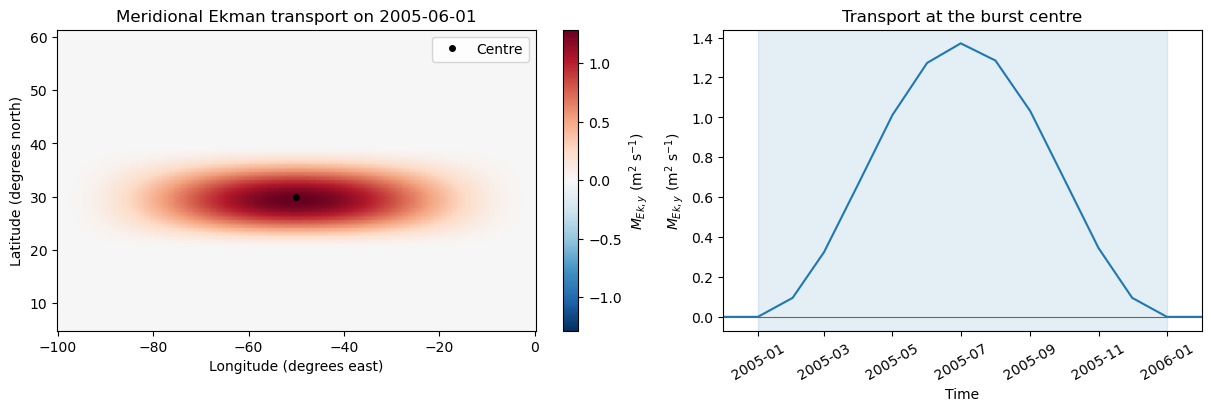

In [4]:
peak_time = np.datetime64("2005-06-01")
centre_latitude = 30.0
centre_longitude = -50.0

peak_transport_native = (
    hlna_burst.M_Ek_y
    .sel(time=peak_time, latitude=slice(5.0, None))
    .compute()
)
western_segment = peak_transport_native.where(
    (peak_transport_native.longitude >= 260.0)
    & (peak_transport_native.longitude < 280.0),
    drop=True,
).assign_coords(longitude=lambda field: field.longitude - 360.0)
eastern_segment = peak_transport_native.where(
    (peak_transport_native.longitude >= -80.0)
    & (peak_transport_native.longitude <= 0.0),
    drop=True,
)
peak_transport = xr.concat(
    [western_segment, eastern_segment], dim="longitude"
)
centre_transport = (
    hlna_burst.M_Ek_y
    .sel(latitude=centre_latitude, longitude=centre_longitude, method="nearest")
    .compute()
)

fig, (map_ax, time_ax) = plt.subplots(
    1, 2, figsize=(12, 4), constrained_layout=True
)
colour_limit = float(np.abs(peak_transport).max())
mesh = map_ax.pcolormesh(
    peak_transport.longitude,
    peak_transport.latitude,
    peak_transport,
    cmap="RdBu_r",
    vmin=-colour_limit,
    vmax=colour_limit,
    shading="auto",
)
map_ax.plot(centre_longitude, centre_latitude, "ko", ms=4, label="Centre")
map_ax.set(
    title=f"Meridional Ekman transport on {np.datetime_as_string(peak_time, unit='D')}",
    xlabel="Longitude (degrees east)",
    ylabel="Latitude (degrees north)",
)
map_ax.legend(loc="upper right")
fig.colorbar(mesh, ax=map_ax, label=r"$M_{Ek,y}$ (m$^2$ s$^{-1}$)")

time_ax.plot(centre_transport.time, centre_transport, color="tab:blue")
time_ax.axhline(0.0, color="0.4", lw=0.8)
time_ax.axvspan(
    np.datetime64("2005-01-01"),
    np.datetime64("2006-01-01"),
    color="tab:blue",
    alpha=0.12,
)
time_ax.set(
    xlim=(np.datetime64("2004-12-01"), np.datetime64("2006-02-01")),
    title="Transport at the burst centre",
    xlabel="Time",
    ylabel=r"$M_{Ek,y}$ (m$^2$ s$^{-1}$)",
)
time_ax.tick_params(axis="x", rotation=30)
plt.show()

In [13]:
# Solve the model
isobath_ds = xr.open_dataset(PROJECT_ROOT / "data/tracked/isobath/global_isobath_GEBCO_1000m.nc").load()
model = GlobalRossbyModel(isobath_ds, g_prime=0.02)
solution = model.solve(hlna_burst)
h_b = solution.h_b.compute()
# Compute the travel times
g = solution.attrs["g_prime_m_s-2"]
H = solution.attrs["isobath_depth_m"]
L = EARTH_RADIUS_M * np.cos(np.radians(isobath_ds.latitude)) * np.radians(isobath_ds.x_eA - isobath_ds.x_wA)
c = rossby_speed(L.latitude, g, H)
tt = L / c

(0.0, 50.0)

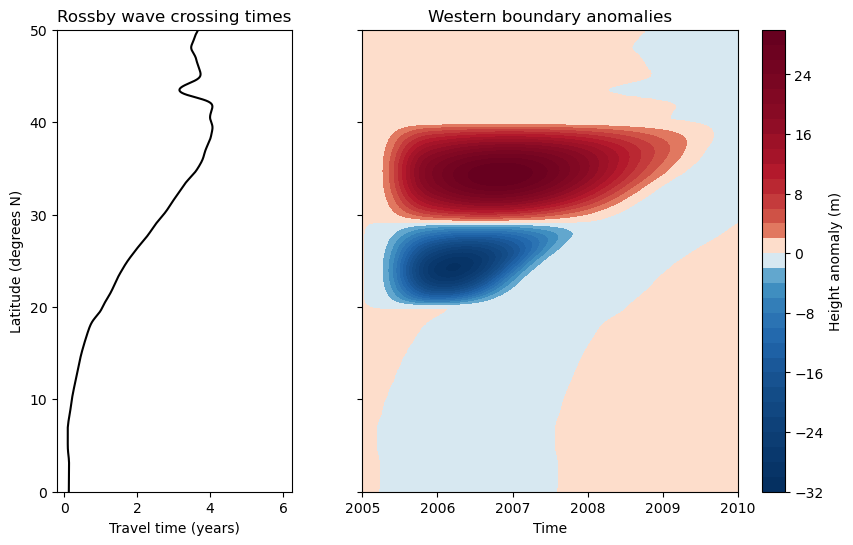

In [26]:
# Plot of travel times and h_b
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), sharey=True, width_ratios=[1, 2])
# Plot travel times
tt_yr = tt / (24 * 60 * 60 * 365.25) # Convert seconds to years
tt_ax = axs[0]
tt_ax.plot(tt_yr, tt_yr.latitude, color="black")
tt_ax.set_xlabel("Travel time (years)")
tt_ax.set_ylabel("Latitude (degrees N)")
tt_ax.set_title("Rossby wave crossing times")
# Plot height anomalies over restricted region
h_b_ax = axs[1]
h_b_to_plot = h_b.sel(region="north_atlantic").sel(time=slice("2005-01-01", "2010-01-01")).sel(latitude=slice(0, 50))
vmax = np.max(np.abs(h_b_to_plot))
ctf = h_b_ax.contourf(h_b_to_plot.time, h_b_to_plot.latitude, h_b_to_plot.T, cmap="RdBu_r", levels=31, norm=mpl.colors.SymLogNorm(linthresh=3))
h_b_ax.set_xlabel("Time")
plt.colorbar(ctf, ax=h_b_ax, label="Height anomaly (m)")
h_b_ax.set_title("Western boundary anomalies")
h_b_ax.set_ylim([h_b_to_plot.latitude.min(), h_b_to_plot.latitude.max()])

In [8]:
# Compute the Ekman upwelling as the divergence of the forcing
x_contribution = hlna_burst.M_Ek_x.differentiate("longitude") / (EARTH_RADIUS_M * np.cos(np.radians(hlna_burst.latitude)) * np.radians(1))
y_contribution = (hlna_burst.M_Ek_y * np.cos(np.radians(hlna_burst.latitude))).differentiate("latitude") / (EARTH_RADIUS_M * np.cos(np.radians(hlna_burst.latitude)) * np.radians(1))
w_Ek = (x_contribution + y_contribution)

In [ ]:
h_b_to_plot

array([[ 0.00404061,  0.004041  ,  0.00404154, ...,  0.00405208,
         0.00405112,  0.0040542 ],
       [ 0.00422263,  0.00422077,  0.00421854, ...,  0.00405831,
         0.00405827,  0.00405415],
       [ 0.00341463,  0.00344225,  0.00347254, ...,  0.00405441,
         0.00405345,  0.00405668],
       ...,
       [ 0.10870941,  0.10885064,  0.10900939, ..., -0.89074032,
        -0.87048408, -0.8484067 ],
       [ 0.0978305 ,  0.09795822,  0.0981018 , ..., -0.92850555,
        -0.91528909, -0.89963671],
       [ 0.08804425,  0.08815883,  0.08828765, ..., -0.94773075,
        -0.94221513, -0.93383621]], shape=(61, 201))